In [54]:
import sys
sys.path.append('..')
from feature_selection import data_feature_selection, split_data, split_data_3way, data_feature_selection_3way

import numpy as np
import time
import pandas as pd
from numpy._core.defchararray import zfill
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix
from os import scandir
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
from sklearn.model_selection import PredefinedSplit
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn import pipeline

In [27]:
# Get the dataset
dataset_final = pd.read_csv("../../data/processed/DatasetMaster.csv")
dataset_final.columns


Index(['time', 'temperature_2m', 'precipitation', 'relative_humidity_2m',
       'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm',
       'soil_moisture_28_to_100cm', 'runoff', 'et0_fao_evapotranspiration',
       'wind_speed_10m', 'wind_gusts_10m', 'alcaldia', 'tema_solicitud',
       'severidad', 'incident', 'mes', 'dia_semana', 'hora_del_dia',
       'es_fin_de_semana', 'precipitation_sum_3h',
       'soil_moisture_0_to_7cm_mean_3h', 'soil_moisture_7_to_28cm_mean_3h',
       'relative_humidity_2m_mean_3h', 'precipitation_sum_6h',
       'soil_moisture_0_to_7cm_mean_6h', 'soil_moisture_7_to_28cm_mean_6h',
       'relative_humidity_2m_mean_6h', 'precipitation_sum_12h',
       'soil_moisture_0_to_7cm_mean_12h', 'soil_moisture_7_to_28cm_mean_12h',
       'relative_humidity_2m_mean_12h', 'precipitation_sum_24h',
       'soil_moisture_0_to_7cm_mean_24h', 'soil_moisture_7_to_28cm_mean_24h',
       'relative_humidity_2m_mean_24h'],
      dtype='str')

In [28]:
# Split data function
X_train, X_test, y_train, y_test = split_data(dataset_final)

In [29]:
# Feature selection
X_train, X_test = data_feature_selection(X_train, X_test)

Original Feature Count: 48
Cleaned Feature Count:  37


In [30]:
X_train.columns

Index(['temperature_2m', 'precipitation', 'relative_humidity_2m',
       'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm',
       'soil_moisture_28_to_100cm', 'et0_fao_evapotranspiration',
       'wind_speed_10m', 'wind_gusts_10m', 'mes', 'dia_semana', 'hora_del_dia',
       'es_fin_de_semana', 'precipitation_sum_3h',
       'relative_humidity_2m_mean_3h', 'precipitation_sum_6h',
       'relative_humidity_2m_mean_6h', 'precipitation_sum_12h',
       'relative_humidity_2m_mean_12h', 'precipitation_sum_24h',
       'relative_humidity_2m_mean_24h', 'alcaldia_ALVARO OBREGON',
       'alcaldia_AZCAPOTZALCO', 'alcaldia_BENITO JUAREZ', 'alcaldia_COYOACAN',
       'alcaldia_CUAJIMALPA DE MORELOS', 'alcaldia_CUAUHTEMOC',
       'alcaldia_GUSTAVO A. MADERO', 'alcaldia_IZTACALCO',
       'alcaldia_IZTAPALAPA', 'alcaldia_MAGDALENA CONTRERAS',
       'alcaldia_MIGUEL HIDALGO', 'alcaldia_MILPA ALTA', 'alcaldia_TLAHUAC',
       'alcaldia_TLALPAN', 'alcaldia_VENUSTIANO CARRANZA',
       'alcaldia_X

In [31]:
# Model creation
# Calculating weight to balance the classes
classes_weights = (y_train == 0).sum() / (y_train == 1).sum()

# initialize the model
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=classes_weights,
    random_state = 42,
    n_jobs = 1, # use all cores in cpu
    eval_metric = 'logloss'
)


In [32]:
# Run the model
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [33]:
predictions_2025 = xgb_model.predict(X_test)

In [34]:
print("Classification Report using 2025 data")
print(classification_report(y_test, predictions_2025))


Classification Report using 2025 data
              precision    recall  f1-score   support

           0       0.79      0.87      0.83    105203
           1       0.71      0.58      0.64     58954

    accuracy                           0.77    164157
   macro avg       0.75      0.73      0.73    164157
weighted avg       0.76      0.77      0.76    164157



Final PR-AUC Score: 0.745


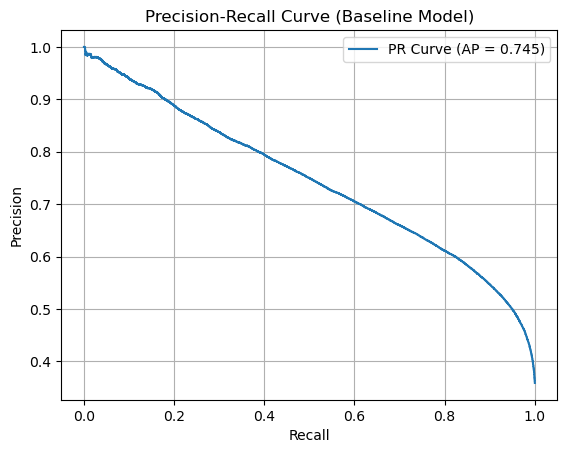

In [35]:
# Obtener probabilidades del modelo baseline
y_scores = xgb_model.predict_proba(X_test)[:, 1]

# Calcular precision-recall
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Calcular PR-AUC
ap = average_precision_score(y_test, y_scores)
print(f"Final PR-AUC Score: {ap:.3f}")

# Graficar
plt.figure()
plt.plot(recall, precision, label=f"PR Curve (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Baseline Model)")
plt.legend()
plt.grid()

plt.show()

In [36]:
tn, fp, fn, tp = confusion_matrix(y_test, predictions_2025).ravel()

print(f"True negatives (predicted safe, was safe): {tn:,}")
print(f"False Positive (predicted incident, was safe): {fp:,} false alarms)")
print(f"False Negatives (predicted safe, was an incident) {fn:,} <- This is the danger, must be low")
print(f"True Positives (predicted incident, was an incident): {tp:,}")

True negatives (predicted safe, was safe): 91,260
False Positive (predicted incident, was safe): 13,943 false alarms)
False Negatives (predicted safe, was an incident) 24,499 <- This is the danger, must be low
True Positives (predicted incident, was an incident): 34,455


## Optimization

Splitting into 3 parts:
1. 2019-2023: training
2. 2024: validation
3. 2025: testing

In [37]:
# Split into 3 sets
X_train, X_val, X_test, y_train, y_val, y_test = split_data_3way(dataset_final)
print(f"Train Matrix (2019-2023): {X_train.shape}")
print(f"Val Matrix   (2024):      {X_val.shape}")
print(f"Test Matrix  (2025):      {X_test.shape}")

Train Matrix (2019-2023): (711299, 50)
Val Matrix   (2024):      (143012, 50)
Test Matrix  (2025):      (164157, 50)


In [38]:
# Feature selection on the sets
X_train, X_val, X_test = data_feature_selection_3way(X_train, X_val, X_test)

print(f"Train Matrix (2019-2023): {X_train.shape}")
print(f"Val Matrix   (2024):      {X_val.shape}")
print(f"Test Matrix  (2025):      {X_test.shape} ")

Train Matrix (2019-2023): (711299, 37)
Val Matrix   (2024):      (143012, 37)
Test Matrix  (2025):      (164157, 37) 


In [39]:
# Hyperparameter tuning with RandomizedSearchCV

# Merge datasets for predefined split
X_tune = pd.concat([X_train, X_val], axis=0)
y_tune = np.concatenate([y_train, y_val])

In [40]:
# PredefinedSplit Array
# -1 : Train
#  0 : Validate
split_map = np.concatenate([
    np.full(len(X_train), -1),
    np.full(len(X_val), 0)
])
fixed_validation = PredefinedSplit(test_fold=split_map)

In [41]:
# XGBoost Engine
classes_weights = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=classes_weights,
    random_state=42,
    n_jobs=-1,      # -1 : full cpu
    tree_method='hist',
    eval_metric='logloss'
)

# different parameters to try
parameters_space = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7]
}

In [42]:
# Execute the Search
search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=parameters_space,
    n_iter=15,
    scoring='average_precision',
    cv=fixed_validation, # <-- The 2024 Validation Barrier is active
    verbose=2,
    random_state=42,
    n_jobs=-1  
)

In [43]:
start_time = time.time()
search.fit(X_tune, y_tune)
end_time = time.time()

print(f"\nExecution Time: {(end_time - start_time) / 60:.2f} minutes")
print("CHAMPION ARCHITECTURE FOUND:")
for param, value in search.best_params_.items():
    print(f"-> {param}: {value}")

print(f"\nChampion PR-AUC on 2024 Validation: {search.best_score_:.4f}")

# Extract the champion model for Phase 3
champion_model = search.best_estimator_

Fitting 1 folds for each of 15 candidates, totalling 15 fits

Execution Time: 1.96 minutes
CHAMPION ARCHITECTURE FOUND:
-> subsample: 0.9
-> min_child_weight: 1
-> max_depth: 9
-> learning_rate: 0.05
-> colsample_bytree: 0.8

Champion PR-AUC on 2024 Validation: 0.4719


The previous score (0.745) was trained on 6 years of data (2019-2024) and tested on one year (2025).
This one is trained on 5 years (2021-2024), and validated on the year 2024 (only one year)
Well pass those to get the optimal decision threshold, and then compare it

In [44]:

# Raw probabilities strictly on the 2024 Validation Set
y_val_proba = champion_model.predict_proba(X_val)[:, 1]

# Precision and Recall across all possible thresholds
precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)

# Find the Optimal F1-Score
# Note: thresholds array is length N, while precision/recall arrays are length N+1.
# We slice precision/recall [:-1] to align the arrays for the calculation.
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9) # prevents division by zero
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Decision Threshold Found: {optimal_threshold:.3f}")
print(f"-> Expected Validation Precision: {precision[optimal_idx]:.3f}")
print(f"-> Expected Validation Recall:    {recall[optimal_idx]:.3f}")
print(f"-> Max Validation F1-Score:       {f1_scores[optimal_idx]:.3f}")

# 4. Optional: Business Logic Override
# In disaster prediction, missing a flood (False Negative) is worse than a false alarm (False Positive).
# If the mathematical optimal threshold is e.g., 0.55, you might manually lower it to 0.40 to favor Recall.
# We will set a variable here so you can easily adjust it before Phase 4.

# Uncomment the line below to manually override the mathematical optimal
# final_decision_threshold = 0.40 
final_decision_threshold = optimal_threshold

print(f"\nFinal Decision Threshold set to: {final_decision_threshold:.3f}")

Optimal Decision Threshold Found: 0.695
-> Expected Validation Precision: 0.452
-> Expected Validation Recall:    0.597
-> Max Validation F1-Score:       0.514

Final Decision Threshold set to: 0.695


For the decision threshold, We might lowet that number to get a better recall than accuracy, since false alarms are not that harmful than a missed disaster, hence we will drop to four different thresholds: 
.40, .50, .60, .70


--- PERFORMANCE SUMMARY TABLE ---
 Threshold  Precision   Recall  F1-Score
       0.4   0.664448 0.716338  0.689418
       0.5   0.716900 0.599298  0.652845
       0.6   0.771760 0.466991  0.581885
       0.7   0.824467 0.324660  0.465869


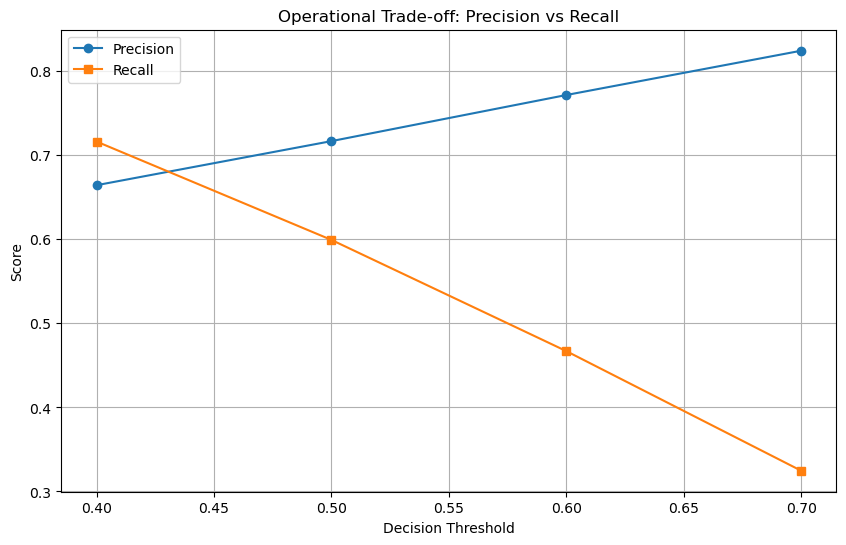

In [45]:
# Thresholds, the lower the more alert will be but more false alarms, the higher the more conservative the model will be but more misses real alarms
thresholds = [0.4, 0.5, 0.6, 0.7]

# Extract raw probabilities
y_test_proba = champion_model.predict_proba(X_test)[:, 1]

# Iterate and Store
sensitivity_results = []

for thresh in thresholds:
    y_pred_iter = (y_test_proba >= thresh).astype(int)
    
    prec = precision_score(y_test, y_pred_iter)
    rec = recall_score(y_test, y_pred_iter)
    f1 = f1_score(y_test, y_pred_iter)
    
    sensitivity_results.append({
        'Threshold': thresh,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

# 4. Display as a clean DataFrame (Publication Ready)
df_sensitivity = pd.DataFrame(sensitivity_results)
print("\n--- PERFORMANCE SUMMARY TABLE ---")
print(df_sensitivity.to_string(index=False))

# Optional: Visualize the trade-off
plt.figure(figsize=(10, 6))
plt.plot(df_sensitivity['Threshold'], df_sensitivity['Precision'], marker='o', label='Precision')
plt.plot(df_sensitivity['Threshold'], df_sensitivity['Recall'], marker='s', label='Recall')
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Operational Trade-off: Precision vs Recall")
plt.legend()
plt.grid(True)
plt.show()


Comparisson (2025)
              precision    recall  f1-score   support

           0       0.83      0.80      0.82    105203
           1       0.66      0.72      0.69     58954

    accuracy                           0.77    164157
   macro avg       0.75      0.76      0.75    164157
weighted avg       0.77      0.77      0.77    164157

Adjusted Confusion matrix
True negatives: 83,876
False Positive (Falsas Alarmas): 21,327 <- Subirán (Es el costo)
False Negatives  (EL PELIGRO): 16,723 <- DEBEN BAJAR
True Positives (SALVADOS): 42,231 <- DEBEN SUBIR

FINAL CHAMPION PR-AUC: 0.751


<Figure size 800x600 with 0 Axes>

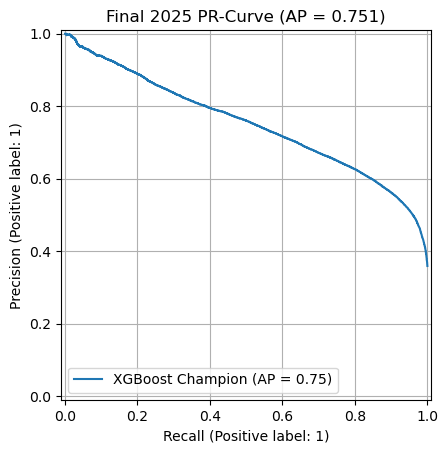

In [52]:
winner_threshold = 0.40 # Since we prefer a high recall rather than precision

# Calculating probabilities for the test set
y_test_proba = champion_model.predict_proba(X_test)[:, 1]

# Predictions based on the winning threshold
y_pred_final = (y_test_proba >= winner_threshold).astype(int)

# Result metrics
print(f"\nComparisson (2025)")
print(classification_report(y_test, y_pred_final))

# PR-AUC
ap_final = average_precision_score(y_test, y_test_proba)
print(f"\nFINAL CHAMPION PR-AUC: {ap_final:.3f}")

# Graph for the RP-AUC Curve
plt.figure(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba, name="XGBoost Champion")
plt.title(f"Final 2025 PR-Curve (AP = {ap_final:.3f})")
plt.grid(True)
plt.show()

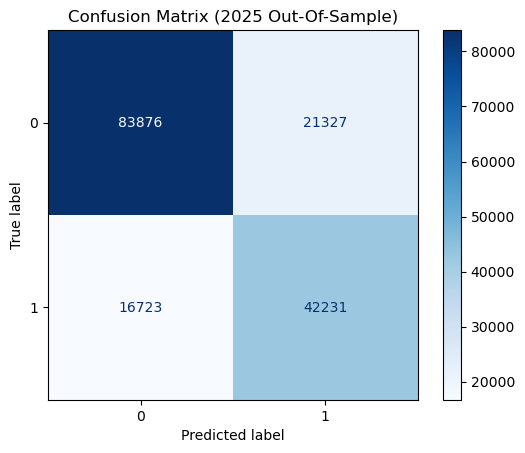

In [56]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=champion_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (2025 Out-Of-Sample)")
plt.show()


In [57]:
# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
print("Adjusted Confusion matrix")
print(f"True negatives: {tn:,}")
print(f"False Positive (Falsas Alarmas): {fp:,} <- Subirán (Es el costo)")
print(f"False Negatives  (EL PELIGRO): {fn:,} <- DEBEN BAJAR")
print(f"True Positives (SALVADOS): {tp:,} <- DEBEN SUBIR")

Adjusted Confusion matrix
True negatives: 83,876
False Positive (Falsas Alarmas): 21,327 <- Subirán (Es el costo)
False Negatives  (EL PELIGRO): 16,723 <- DEBEN BAJAR
True Positives (SALVADOS): 42,231 <- DEBEN SUBIR
